## Reasoning Patch

In [1]:
%load_ext autoreload
%autoreload 2

### Overview

### Set-up

In [2]:
import torch
import gc
import pandas as pd
from tqdm import tqdm

import sys
sys.path.append("src")
import _util
import _mapping
import _prompt
from _intervention import prepare_batch_multitoken_intervention, batch_intervene, forward_with_cache, prepare_batch_multitoken_steering

In [3]:
_util.print_GPU_availbility()

CUDA is available: True
Available devices:
  GPU 0: NVIDIA RTX A5500
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B

In [4]:
model_type = "GPT-OSS" # GPT-OSS or R1

if model_type == "GPT-OSS":
    model, tokenizer = _util.load_OSS()
elif model_type == "R1":
    model, tokenizer = _util.load_R1()

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [5]:
prompt_type = "h_pre_result" # empty or pre_result or pre_final_sum or h or h_pre_result or h_pre_final_sum
if prompt_type:
    prompt_type = "_" + prompt_type

# Load the divided prompts dataset
if 'h1' in prompt_type:
    prompts = pd.read_csv(f"data/{model_type}/h1_prompts{prompt_type[3:]}.csv")
elif 'h' in prompt_type:
    prompts = pd.read_csv(f"data/{model_type}/h_prompts{prompt_type[2:]}.csv")
else:
    prompts = pd.read_csv(f"data/{model_type}/prompts{prompt_type}.csv")
prompts["base_sum"] = prompts["base_sum"].astype('Int64')
prompts["source_sum"] = prompts["source_sum"].astype('Int64')
print(f"loaded {len(prompts)} prompts")

loaded 256 prompts


In [6]:
intervention_loc = [25] # restatement or reasoning or restatement_and_reasoning

if type(intervention_loc) == str:
    if 'h' in prompt_type:
        if model_type == "GPT-OSS":
            intervention_ids_dict = _mapping.intervene_ids_stepwise_3_digit_h
        elif model_type == "R1":
            intervention_ids_dict = _mapping.intervene_ids_R1_3_digit_h
    else:
        if model_type == "GPT-OSS":
            intervention_ids_dict = _mapping.intervene_ids_stepwise_3_digit
        elif model_type == "R1":
            intervention_ids_dict = _mapping.intervene_ids_R1_3_digit

    if intervention_loc == "restatement":
        intervention_ids = intervention_ids_dict["restatement"]
    elif intervention_loc == "reasoning":
        intervention_ids = intervention_ids_dict["reasoning"]
    elif intervention_loc == "restatement_and_reasoning":
        intervention_ids = intervention_ids_dict["restatement"] + intervention_ids_dict["reasoning"]
elif type(intervention_loc) == list:
    intervention_ids = intervention_loc

print(intervention_ids)

[25]


In [7]:
# for i, row in prompts.iterrows():
#     base_prompt = row['base_prompt']
#     source_prompt = row['source_prompt']
#     base_prompt = tokenizer(base_prompt, add_special_tokens=False, return_tensors="pt")["input_ids"][0]
#     source_prompt = tokenizer(source_prompt, add_special_tokens=False, return_tensors="pt")["input_ids"][0]
#     base_prompt_len = base_prompt.shape[0]
#     source_prompt_len = source_prompt.shape[0]
#     print(f"base_prompt_len: {base_prompt_len}, source_prompt_len: {source_prompt_len}")
#     print(list(enumerate(tokenizer.convert_ids_to_tokens(base_prompt))))
#     print(list(enumerate(tokenizer.convert_ids_to_tokens(source_prompt))))

# # [112, 202, 212]
# # [110, 112, 199, 202, 209, 212]
    

In [7]:
intervention_id_to_tok_pos = {
    6: 93,
    8: 111,
    10: 201,
    12: 211,
    14: 217,
    18: 229,
    19: 232,
    20: 235,
    22: 241,
    23: 244,
    25: 250,
    26: 257,
    27: 266,
}

tok_pos_list = [intervention_id_to_tok_pos[id] for id in intervention_ids]
print(tok_pos_list)


[250]


In [9]:
# STEERING_LAYER = 16
# STEERING_DIRECTION = "negative"
# if STEERING_DIRECTION == "negative":
#     coefficient = -0.333
# else:
#     coefficient = 1
# steering_vectors = torch.load("experiments/activation_intervention/steering_vectors_gpt-oss-20b.pt")
# backtracking_vectors = steering_vectors["backtracking"]["mean"]

## Frozen Attention Patching

In [11]:
LAYER = 16
device = "cuda:4"

batch_size = 24

natural_activation_sum = torch.zeros(2880).to(device)
intervened_activation_sum = torch.zeros(2880).to(device)

for i in tqdm(range(0, len(prompts), batch_size)):
    torch.cuda.empty_cache()
    gc.collect()
    batch_rows = prompts.iloc[i:i+batch_size]

    tokens = tokenizer(batch_rows['base_prompt'].tolist(), add_special_tokens=False, return_tensors="pt", padding=True, padding_side="left").to(model.device)

    _, cache = forward_with_cache(model, tokens["input_ids"], attention_mask=tokens["attention_mask"])
    activations = cache[f"model.layers.{LAYER}"][:,tok_pos_list,:]
    natural_activation_sum = natural_activation_sum + activations.sum(dim=0).sum(dim=0)
    
    intervention_prompts = [_prompt.get_intervened_prompt(intervention_ids, row['base_prompt'], row['source_prompt']) for _, row in batch_rows.iterrows()]
    intervened_tokens = tokenizer(intervention_prompts, add_special_tokens=False, return_tensors="pt", padding=True, padding_side="left").to(model.device)

    _, intervened_cache = forward_with_cache(model, intervened_tokens["input_ids"], attention_mask=intervened_tokens["attention_mask"])
    intervened_activations = intervened_cache[f"model.layers.{LAYER}"][:,tok_pos_list,:]
    intervened_activation_sum = intervened_activation_sum + intervened_activations.sum(dim=0).sum(dim=0)

    del tokens, intervened_tokens, cache, intervened_cache
    torch.cuda.empty_cache()
    gc.collect()

mean_natural_activation = natural_activation_sum / len(prompts)
mean_intervened_activation = intervened_activation_sum / len(prompts)
   


  0%|                                                                             | 0/11 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████| 11/11 [02:03<00:00, 11.20s/it]


In [21]:
steering_vectors = torch.load("experiments/activation_intervention/steering_vectors_gpt-oss-20b.pt")
steering_vector = steering_vectors["backtracking"]["mean"][LAYER].to(device)
print(torch.nn.functional.cosine_similarity(steering_vector, mean_intervened_activation - mean_natural_activation, dim=0))
print(torch.nn.functional.cosine_similarity(steering_vector, mean_natural_activation, dim=0))
print(torch.nn.functional.cosine_similarity(steering_vector, mean_intervened_activation, dim=0))

scalar_projection = torch.dot(mean_intervened_activation - mean_natural_activation, steering_vector) / torch.norm(steering_vector)
print(scalar_projection)
print(scalar_projection / torch.norm(steering_vector))
print(torch.norm(steering_vector))
print(torch.norm(mean_intervened_activation - mean_natural_activation))
print(torch.norm(mean_intervened_activation))
print(torch.norm(mean_natural_activation))

tensor(0.0924, device='cuda:4')
tensor(0.7897, device='cuda:4')
tensor(0.8081, device='cuda:4')
tensor(53.3009, device='cuda:4')
tensor(0.0173, device='cuda:4')
tensor(3078.5500, device='cuda:4')
tensor(576.7673, device='cuda:4')
tensor(3324.3523, device='cuda:4')
tensor(3334.4717, device='cuda:4')


In [22]:
# torch.save((mean_intervened_activation - mean_natural_activation).detach().cpu(), "experiments/activation_intervention/intervention_effect_gpt-oss-20b.pt")

In [14]:
LAYER = 16
device = "cuda:4"

steering_vectors = torch.load("experiments/activation_intervention/steering_vectors_gpt-oss-20b.pt")
steering_vector = steering_vectors["backtracking"]["mean"][LAYER].to(device).to(torch.bfloat16)
mean_diff_vector = torch.load("experiments/activation_intervention/intervention_effect_gpt-oss-20b.pt").to(device).to(torch.bfloat16)

def get_scalar_projection(vector_1, vector_2):
    return torch.dot(vector_1, vector_2) / torch.norm(vector_2)

In [15]:
batch_size = 24

backtrack_cosine_similarities = []
backtrack_scalar_projection_ratios = []
mean_diff_cosine_similarities = []
mean_diff_scalar_projection_ratios = []
for i in tqdm(range(0, len(prompts), batch_size)):
    torch.cuda.empty_cache()
    gc.collect()
    batch_rows = prompts.iloc[i:i+batch_size]

    tokens = tokenizer(batch_rows['base_prompt'].tolist(), add_special_tokens=False, return_tensors="pt", padding=True, padding_side="left").to(model.device)

    _, cache = forward_with_cache(model, tokens["input_ids"], attention_mask=tokens["attention_mask"])
    activations = cache[f"model.layers.{LAYER}"][:,tok_pos_list,:]
    
    intervention_prompts = [_prompt.get_intervened_prompt(intervention_ids, row['base_prompt'], row['source_prompt']) for _, row in batch_rows.iterrows()]
    intervened_tokens = tokenizer(intervention_prompts, add_special_tokens=False, return_tensors="pt", padding=True, padding_side="left").to(model.device)

    _, intervened_cache = forward_with_cache(model, intervened_tokens["input_ids"], attention_mask=intervened_tokens["attention_mask"])
    intervened_activations = intervened_cache[f"model.layers.{LAYER}"][:,tok_pos_list,:]

    for intervened_activation, activation in zip(intervened_activations, activations):
        diff = intervened_activation[0] - activation[0]
        backtrack_cosine_similarities.append(torch.nn.functional.cosine_similarity(diff, steering_vector, dim=0))
        backtrack_scalar_projection_ratios.append(get_scalar_projection(diff, steering_vector) / torch.norm(steering_vector))
        mean_diff_cosine_similarities.append(torch.nn.functional.cosine_similarity(diff, mean_diff_vector, dim=0))
        mean_diff_scalar_projection_ratios.append(get_scalar_projection(diff, mean_diff_vector) / torch.norm(mean_diff_vector))

    del tokens, intervened_tokens, cache, intervened_cache
    torch.cuda.empty_cache()
    gc.collect()
   


  0%|                                                                             | 0/11 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████| 11/11 [02:03<00:00, 11.19s/it]


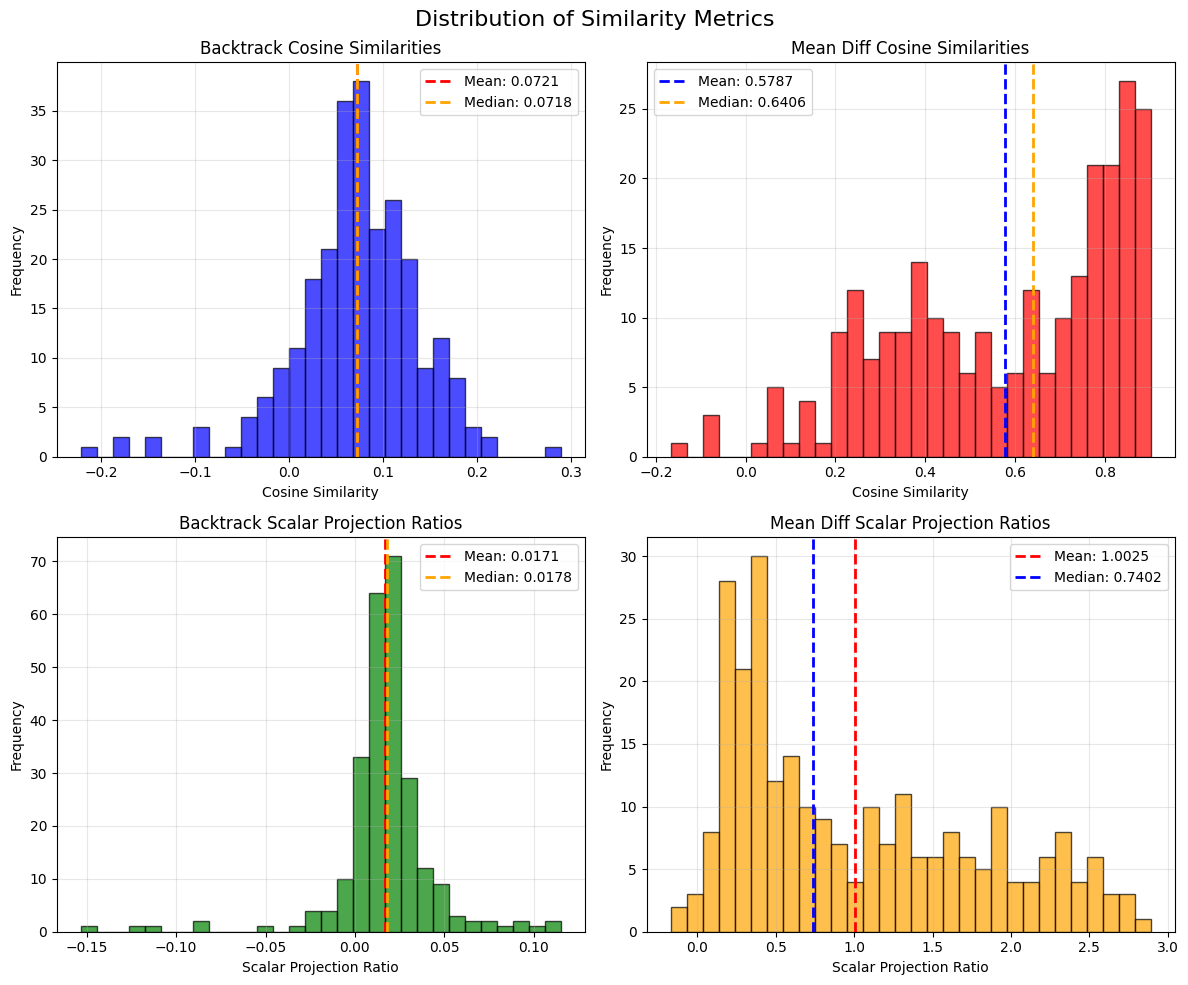

Summary Statistics:
Backtrack Cosine Similarities - Mean: 0.0721, Median: 0.0718, Std: 0.0669
Mean Diff Cosine Similarities - Mean: 0.5787, Median: 0.6406, Std: 0.2564
Backtrack Scalar Projection Ratios - Mean: 0.0171, Median: 0.0178, Std: 0.0273
Mean Diff Scalar Projection Ratios - Mean: 1.0025, Median: 0.7402, Std: 0.7823


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Convert tensors to numpy arrays for plotting
backtrack_cosine_similarities_np = [sim.cpu().to(torch.float32).numpy() for sim in backtrack_cosine_similarities]
mean_diff_cosine_similarities_np = [sim.cpu().to(torch.float32).numpy() for sim in mean_diff_cosine_similarities]
backtrack_scalar_projection_ratios_np = [ratio.cpu().to(torch.float32).numpy() for ratio in backtrack_scalar_projection_ratios]
mean_diff_scalar_projection_ratios_np = [ratio.cpu().to(torch.float32).numpy() for ratio in mean_diff_scalar_projection_ratios]

# Calculate statistics
backtrack_cos_mean = np.mean(backtrack_cosine_similarities_np)
backtrack_cos_median = np.median(backtrack_cosine_similarities_np)
mean_diff_cos_mean = np.mean(mean_diff_cosine_similarities_np)
mean_diff_cos_median = np.median(mean_diff_cosine_similarities_np)
backtrack_proj_mean = np.mean(backtrack_scalar_projection_ratios_np)
backtrack_proj_median = np.median(backtrack_scalar_projection_ratios_np)
mean_diff_proj_mean = np.mean(mean_diff_scalar_projection_ratios_np)
mean_diff_proj_median = np.median(mean_diff_scalar_projection_ratios_np)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribution of Similarity Metrics', fontsize=16)

# Plot backtrack cosine similarities
axes[0, 0].hist(backtrack_cosine_similarities_np, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].axvline(backtrack_cos_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {backtrack_cos_mean:.4f}')
axes[0, 0].axvline(backtrack_cos_median, color='orange', linestyle='--', linewidth=2, label=f'Median: {backtrack_cos_median:.4f}')
axes[0, 0].set_title('Backtrack Cosine Similarities')
axes[0, 0].set_xlabel('Cosine Similarity')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Plot mean diff cosine similarities
axes[0, 1].hist(mean_diff_cosine_similarities_np, bins=30, alpha=0.7, color='red', edgecolor='black')
axes[0, 1].axvline(mean_diff_cos_mean, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_diff_cos_mean:.4f}')
axes[0, 1].axvline(mean_diff_cos_median, color='orange', linestyle='--', linewidth=2, label=f'Median: {mean_diff_cos_median:.4f}')
axes[0, 1].set_title('Mean Diff Cosine Similarities')
axes[0, 1].set_xlabel('Cosine Similarity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Plot backtrack scalar projection ratios
axes[1, 0].hist(backtrack_scalar_projection_ratios_np, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1, 0].axvline(backtrack_proj_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {backtrack_proj_mean:.4f}')
axes[1, 0].axvline(backtrack_proj_median, color='orange', linestyle='--', linewidth=2, label=f'Median: {backtrack_proj_median:.4f}')
axes[1, 0].set_title('Backtrack Scalar Projection Ratios')
axes[1, 0].set_xlabel('Scalar Projection Ratio')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Plot mean diff scalar projection ratios
axes[1, 1].hist(mean_diff_scalar_projection_ratios_np, bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1, 1].axvline(mean_diff_proj_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_diff_proj_mean:.4f}')
axes[1, 1].axvline(mean_diff_proj_median, color='blue', linestyle='--', linewidth=2, label=f'Median: {mean_diff_proj_median:.4f}')
axes[1, 1].set_title('Mean Diff Scalar Projection Ratios')
axes[1, 1].set_xlabel('Scalar Projection Ratio')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary Statistics:")
print(f"Backtrack Cosine Similarities - Mean: {backtrack_cos_mean:.4f}, Median: {backtrack_cos_median:.4f}, Std: {np.std(backtrack_cosine_similarities_np):.4f}")
print(f"Mean Diff Cosine Similarities - Mean: {mean_diff_cos_mean:.4f}, Median: {mean_diff_cos_median:.4f}, Std: {np.std(mean_diff_cosine_similarities_np):.4f}")
print(f"Backtrack Scalar Projection Ratios - Mean: {backtrack_proj_mean:.4f}, Median: {backtrack_proj_median:.4f}, Std: {np.std(backtrack_scalar_projection_ratios_np):.4f}")
print(f"Mean Diff Scalar Projection Ratios - Mean: {mean_diff_proj_mean:.4f}, Median: {mean_diff_proj_median:.4f}, Std: {np.std(mean_diff_scalar_projection_ratios_np):.4f}")
